# Análisis exploratorio de datos


In [208]:
import pandas as pd
import seaborn as sns 
import matplotlib. pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from utils2 import get_regression_metrics
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV, ElasticNet

## Paso 1: Definición del problema

> ¿Existe alguna relación entre los recursos sanitarios y los datos socio demográficos por condado en los Estados Unidos?

## Paso 2: Recopilación de datos

> Dataset de [medical_insurance_cost](https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv
)

### Importamos los datos y creamos el DataFrame

In [209]:
#Data collection
df = pd.read_csv("/workspaces/CarlosRestrepo-machine-learning-python/data/raw/demographic_health_data.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## Paso 3: Análisis Descriptivo

In [210]:
df

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,6104,14.178532,6326,14.694200,5359,12.448027,6577,15.277229,...,2098,8.9,8.3,9.6,2834,2.6,2.4,2.8,821,5
3136,56039,23081,2384,10.328842,2185,9.466661,2967,12.854729,4093,17.733200,...,928,7.2,6.5,8.0,1360,2.4,2.2,2.6,447,5
3137,56041,20299,3121,15.375142,3205,15.788955,2153,10.606434,2702,13.311001,...,1163,10.4,9.5,11.2,1500,3.0,2.8,3.2,430,5
3138,56043,7885,858,10.881420,1113,14.115409,715,9.067850,903,11.452124,...,506,11.3,10.3,12.1,686,3.4,3.2,3.7,207,6


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(2)
memory usage: 2.6+ MB


In [212]:
df.isnull().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

### Observaciones:

> ### Observaciones:
> - Existen un total de 3140 filas y 108 columnas, entre las cuales encontramos el target o clase a predecir, `Active Physicians per 100000 Population 2018 (AAMC)`.
> - Ninguna variable contiene valores nulos.
> - Los datos cuentan con 106 características numéricas y 2 características categóricas.

## Paso 4: Limpieza de Datos

### Limpieza de datos: Eliminar duplicados

In [213]:
df.duplicated().sum()

np.int64(0)

> - No haya filas duplicadas

### Limpieza de datos: Eliminar información irrelevante

In [214]:
#Remove non-esential colums from the DataFrame.
df = df.drop(['fips', 'STATE_FIPS', 'CNTY_FIPS', '0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 
              'White-alone pop', 'Black-alone pop', 'Native American/American Indian-alone pop', 'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop',
              'Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18",
              'TOT_POP', 'GQ_ESTIMATES_2018', 'COUNTY_NAME', 'STATE_NAME', 'Total Population', 'Population Aged 60+','CI90LBINC_2018', 'CI90UBINC_2018', 
              'Obesity_Upper 95% CI', 'Heart disease_Upper 95% CI', 'COPD_Upper 95% CI', 'diabetes_Upper 95% CI', 'CKD_Upper 95% CI', 'R_NATURAL_INC_2018', 'R_NET_MIG_2018', 'R_DOMESTIC_MIG_2018', 'county_pop2018_18 and older',
              'anycondition_Lower 95% CI', 'Obesity_Lower 95% CI', 'Heart disease_Lower 95% CI', 'COPD_Lower 95% CI', 'diabetes_Lower 95% CI', 'CKD_Lower 95% CI','Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)', 
              'Active Primary Care Physicians per 100000 Population 2018 (AAMC)', 'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)', 'Active General Surgeons per 100000 Population 2018 (AAMC)',
              'Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)'], axis=1)
df

,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,...,Obesity_number,Heart disease_prevalence,Heart disease_number,COPD_prevalence,COPD_number,diabetes_prevalence,diabetes_number,CKD_prevalence,CKD_number,Urban_rural_code
0,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,...,15193,7.9,3345,8.6,3644,12.9,5462,3.1,1326,3
1,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,...,50761,7.8,13414,8.6,14692,12.0,20520,3.2,5479,4
2,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,...,8013,11.0,2159,12.1,2373,19.7,3870,4.5,887,6
3,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,...,6894,8.6,1533,10.0,1789,14.1,2511,3.3,595,2
4,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,...,15112,9.2,4101,10.5,4661,13.5,6017,3.4,1507,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,14.178532,14.694200,12.448027,15.277229,12.389956,12.220390,11.481731,5.105572,2.204362,93.835219,...,10672,5.9,1862,6.6,2098,8.9,2834,2.6,821,5
3136,10.328842,9.466661,12.854729,17.733200,14.830380,12.685759,12.456133,6.797799,2.846497,95.190850,...,3655,5.2,981,4.9,928,7.2,1360,2.4,447,5
3137,15.375142,15.788955,10.606434,13.311001,11.773979,11.990738,12.581901,6.074191,2.497660,95.354451,...,4944,7.2,1034,8.0,1163,10.4,1500,3.0,430,5
3138,10.881420,14.115409,9.067850,11.452124,11.414077,13.760304,14.178821,9.397590,5.732403,94.483196,...,1730,8.2,500,8.3,506,11.3,686,3.4,207,6


#### Observaciones:
> - Se han eliminado el siguiente tipo de columnas:
    > - Variables de Metadatos y FIPS.
    > - Columnas Redundantes (Duplicación de Porcentaje vs. Conteo).
    > - Columnas de Conteo Redundantes (Estimaciones).
    > - Intervalos de Confianza (CI).
    > - Columnas Calculadas y Similares.

## Paso 5: Análisis de Variables

### Análisis de Variables Univariante

#### Análisis de Variables Univariante Categóricas

In [215]:
df.select_dtypes(include='object')

""
0
1
2
3
4
...
3135
3136
3137
3138


##### Observaciones:
> - Después de la limpieza de columnas no esenciales, no tenemos ninguna columna categórica, de las dos con las que iniciamos el DataFrame.

#### Análisis de Variables Univariante Numéricas

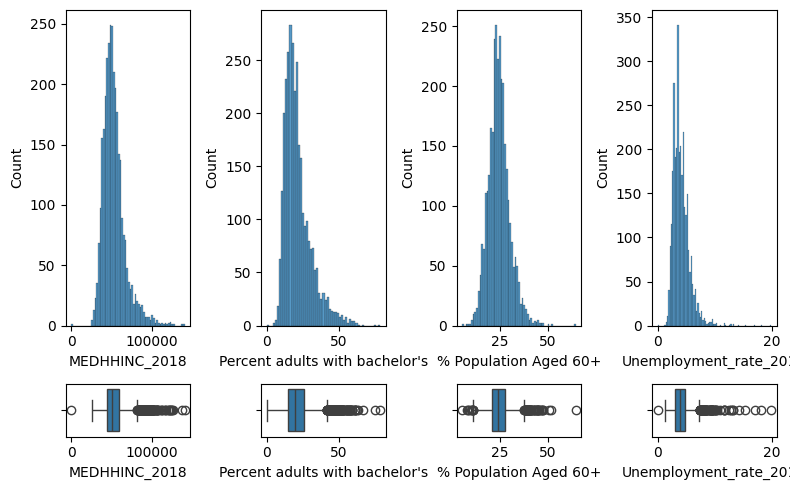

In [216]:
fig, axis = plt.subplots(2, 4, figsize=(8, 5), gridspec_kw={'height_ratios': [6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax=axis[0, 0], data=df, x="MEDHHINC_2018")
sns.boxplot(ax=axis[1, 0], data=df, x="MEDHHINC_2018")

sns.histplot(ax=axis[0, 1], data=df, x="Percent of adults with a bachelor's degree or higher 2014-18",).set(xlabel="Percent adults with bachelor's")
sns.boxplot(ax=axis[1, 1], data=df, x="Percent of adults with a bachelor's degree or higher 2014-18").set(xlabel="Percent adults with bachelor's")

sns.histplot(ax=axis[0, 2], data=df, x="Percent of Population Aged 60+").set(xlabel='% Population Aged 60+')
sns.boxplot(ax=axis[1, 2], data=df, x="Percent of Population Aged 60+").set(xlabel='% Population Aged 60+')

sns.histplot(ax=axis[0, 3], data=df, x="Unemployment_rate_2018")
sns.boxplot(ax=axis[1, 3], data=df, x="Unemployment_rate_2018")

plt.tight_layout()


> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener en claro que las características cuentan con valores atípicos.

### Análisis de Variables Multivariante

#### Análisis numérico-numérico

##### charges - (age, bmi, children)
Primero analizamos el target frente a las características numéricas:

/tmp/ipykernel_10808/2747682587.py:23: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


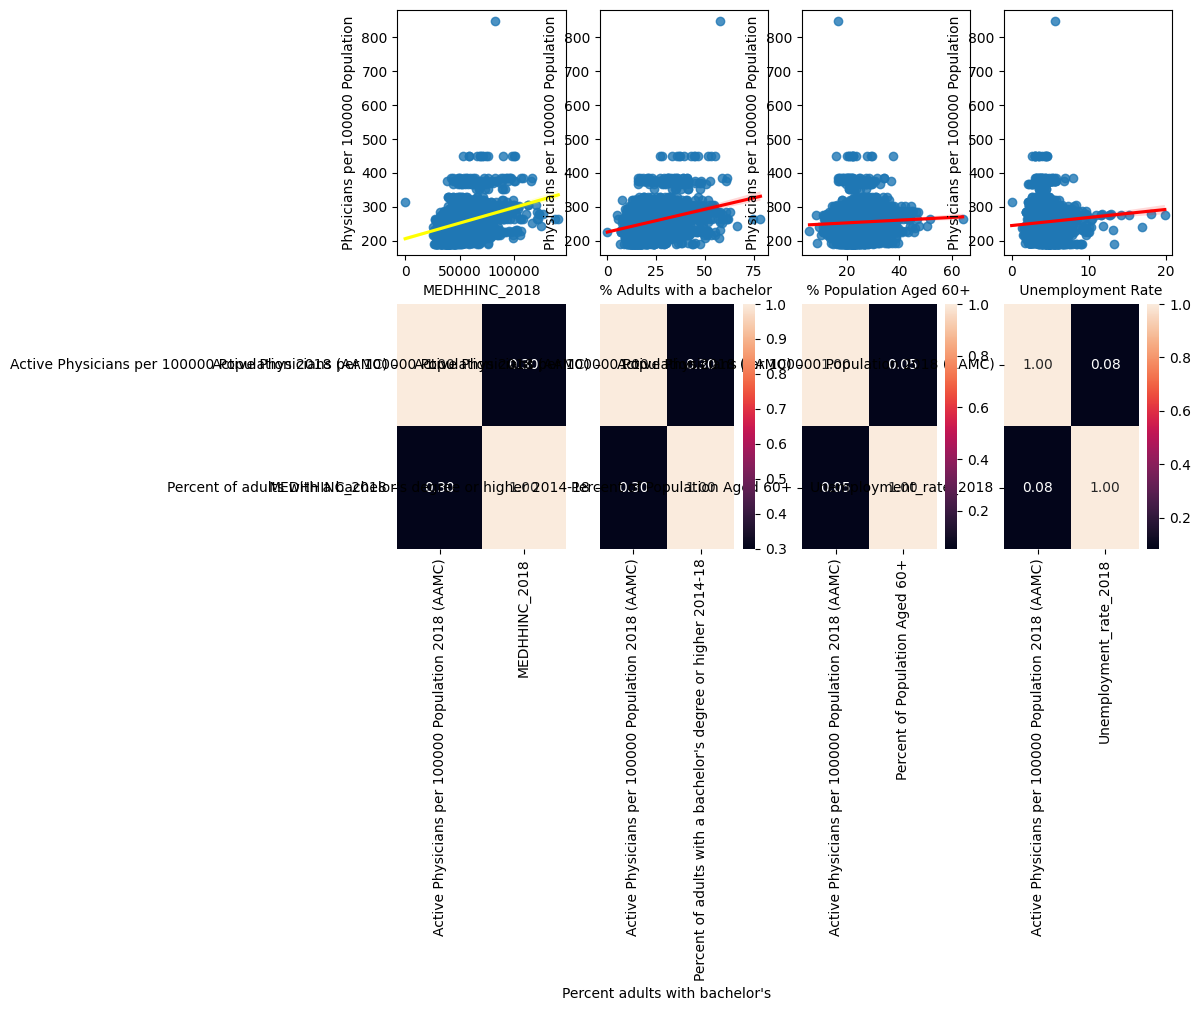

In [217]:
# Generamos las correlaciones
corr_active_med = df[["Active Physicians per 100000 Population 2018 (AAMC)", "MEDHHINC_2018"]].corr()
corr_active_percent_adults = df[["Active Physicians per 100000 Population 2018 (AAMC)", "Percent of adults with a bachelor's degree or higher 2014-18"]].corr()
corr_active_percent_population = df[["Active Physicians per 100000 Population 2018 (AAMC)", "Percent of Population Aged 60+"]].corr()
corr_active_unemployment_rate = df[["Active Physicians per 100000 Population 2018 (AAMC)", "Unemployment_rate_2018"]].corr()


# Crear un diagrama de dispersión múltiple
fig, axis = plt.subplots(2, 4, figsize=(10, 7))

sns.regplot(ax=axis[0, 0], data=df, x="MEDHHINC_2018", y="Active Physicians per 100000 Population 2018 (AAMC)", line_kws={'color': 'yellow'}).set(ylabel='Physicians per 100000 Population', xlabel="MEDHHINC_2018")
sns.heatmap(ax=axis[1, 0], data=corr_active_med, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="Percent of adults with a bachelor's degree or higher 2014-18", y="Active Physicians per 100000 Population 2018 (AAMC)", line_kws={'color': 'red'}).set(ylabel='Physicians per 100000 Population', xlabel=" % Adults with a bachelor")
sns.heatmap(ax=axis[1, 1], data=corr_active_percent_adults, annot=True, fmt=".2f").set(xlabel="Percent adults with bachelor's")

sns.regplot(ax=axis[0, 2], data=df, x="Percent of Population Aged 60+", y="Active Physicians per 100000 Population 2018 (AAMC)", line_kws={'color': 'red'}).set(ylabel='Physicians per 100000 Population', xlabel=" % Population Aged 60+")
sns.heatmap(ax=axis[1, 2], data=corr_active_percent_population, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 3], data=df, x="Unemployment_rate_2018", y="Active Physicians per 100000 Population 2018 (AAMC)", line_kws={'color': 'red'}).set(ylabel='Physicians per 100000 Population', xlabel=" Unemployment Rate")
sns.heatmap(ax=axis[1, 3], data=corr_active_unemployment_rate, annot=True, fmt=".2f")

plt.tight_layout()

##### Análisis de correlaciones

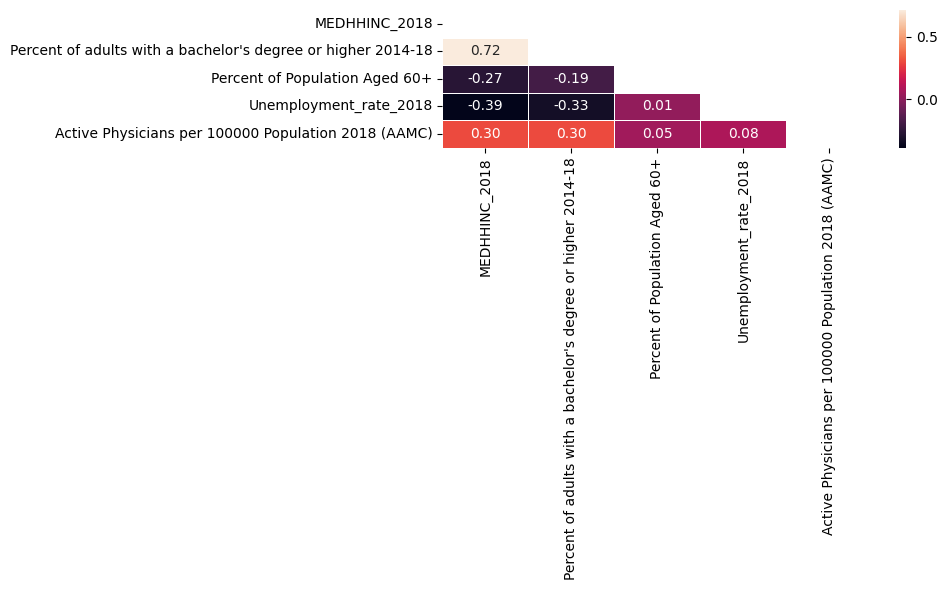

In [218]:
corr = df[["MEDHHINC_2018", "Percent of adults with a bachelor's degree or higher 2014-18", "Percent of Population Aged 60+", "Unemployment_rate_2018", "Active Physicians per 100000 Population 2018 (AAMC)"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

> ##### Observaciones:
>
> - El análisis de correlaciones refleja una fuerte relación directa entre el porcentaje de personas mayores con un título de licenciatura y el ingreso del hogar (MEDHHINC_2018).
> - El porcentaje de población mayor de 60 años tiene una correlación negativa con los ingresos anuales del hogar (MEDHHINC_2018), así mismo (MEDHHINC_2018), tiene una correlación negativa con tasa de desempleo (Unemployment_rate_2018).
> - La variable médicos activos (Active physicians per 100000 Population 2018 (AAMC), tiene una correlación positiva con el ingreso anual del hogar y el porcentaje de adultos con título de licenciatura

## Paso 6: Ingeniería de características

#### Análisis de outliers

**Outliers: Análisis descriptivo**

In [219]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.000000,10.594639,11.802727,12.951840,2.546068e+01
10-19 y/o % of total pop,3140.0,12.694609,1.815044,0.000000,11.674504,12.687422,13.659282,2.330437e+01
20-29 y/o % of total pop,3140.0,12.283979,3.126297,0.000000,10.496774,11.772649,13.182260,3.757020e+01
30-39 y/o % of total pop,3140.0,11.751535,1.696599,6.092789,10.689322,11.580861,12.639379,2.222513e+01
40-49 y/o % of total pop,3140.0,11.556685,1.372935,2.631579,10.685197,11.618372,12.386083,1.943037e+01
50-59 y/o % of total pop,3140.0,13.526733,1.481692,5.316361,12.738561,13.621339,14.429115,2.045455e+01
60-69 y/o % of total pop,3140.0,13.182225,2.532498,3.444403,11.621232,13.013409,14.467254,2.727273e+01
70-79 y/o % of total pop,3140.0,8.399382,2.214915,2.199551,7.032275,8.208162,9.445777,3.132796e+01
80+ y/o % of total pop,3140.0,4.733801,1.535028,0.000000,3.738648,4.565338,5.484143,2.272727e+01
% White-alone,3140.0,84.494109,16.348987,3.841985,79.620473,91.410189,95.521727,9.904378e+01


##### Observaciones:
> - Se puede apreciar como la mayoría de características tienen outliers y como hay valores de 0 en ciertos rangos de edad medidos en porcentaje de la población.

#### **Outliers: Visualización**

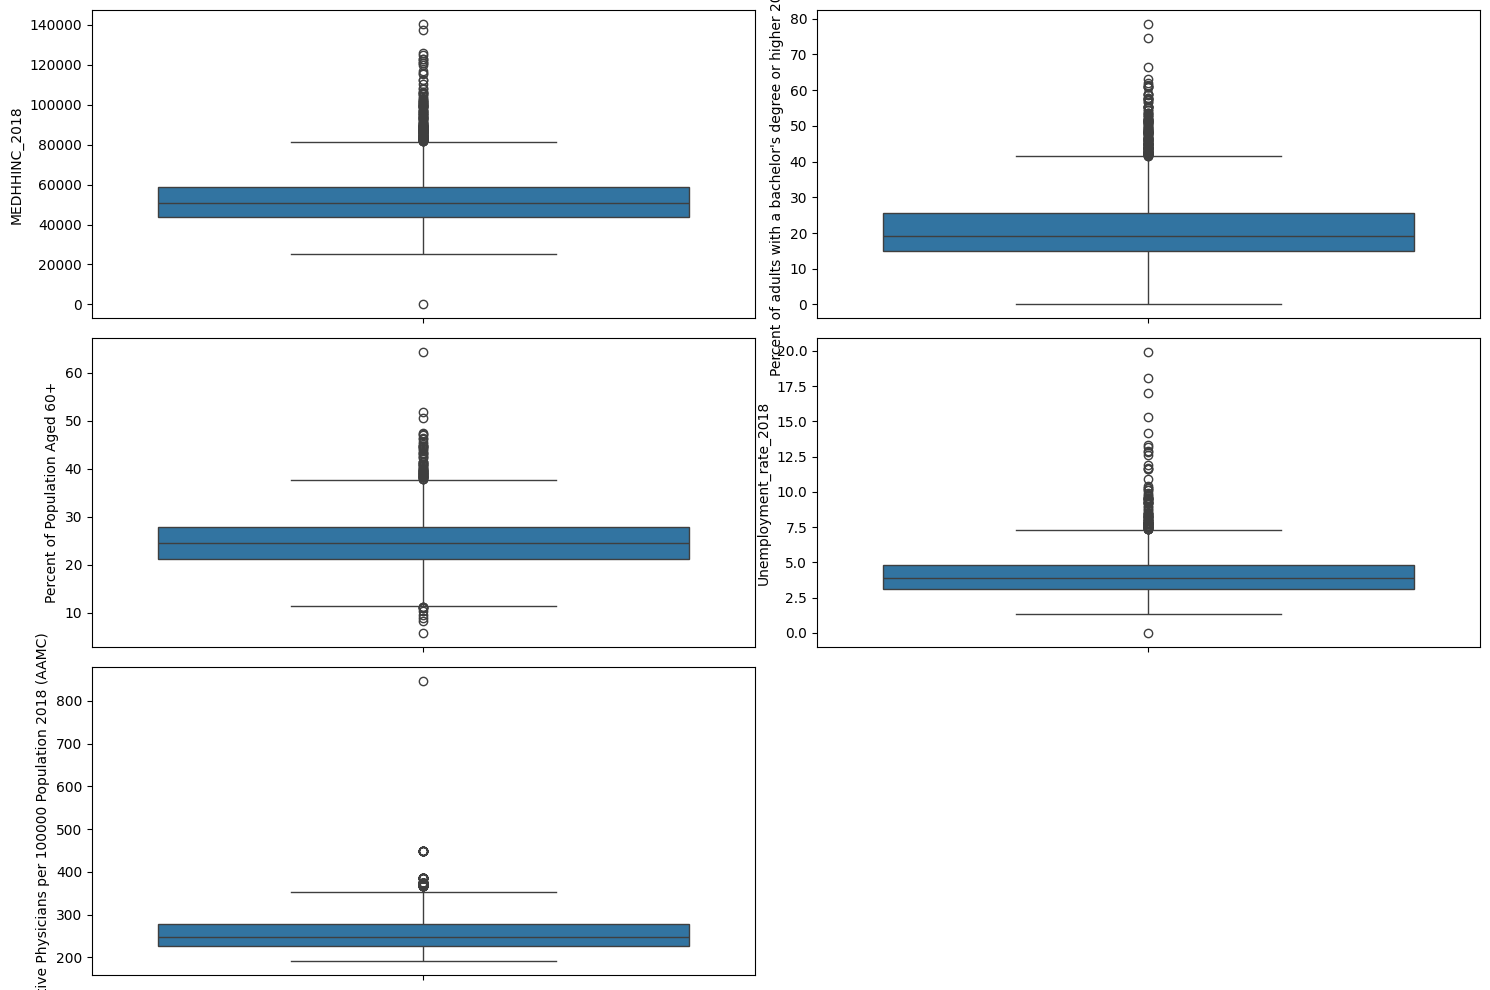

In [220]:
fig, axis = plt.subplots(3, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df, y="MEDHHINC_2018")
sns.boxplot(ax=axis[0, 1], data=df, y="Percent of adults with a bachelor's degree or higher 2014-18")
sns.boxplot(ax=axis[1, 0], data=df, y="Percent of Population Aged 60+")
sns.boxplot(ax=axis[1, 1], data=df, y="Unemployment_rate_2018")
sns.boxplot(ax=axis[2, 0], data=df, y="Active Physicians per 100000 Population 2018 (AAMC)")

fig.delaxes(axis[2, 1])

plt.tight_layout()
plt.show()

> #### Observaciones DE EJEMPLO
>
> - Con esta visualización se confirma el análisis anterior donde se indica la presencia de outliers para la mayoría de las variables.

In [221]:
df.isnull().sum()

0-9 y/o % of total pop                                                     0
10-19 y/o % of total pop                                                   0
20-29 y/o % of total pop                                                   0
30-39 y/o % of total pop                                                   0
40-49 y/o % of total pop                                                   0
50-59 y/o % of total pop                                                   0
60-69 y/o % of total pop                                                   0
70-79 y/o % of total pop                                                   0
80+ y/o % of total pop                                                     0
% White-alone                                                              0
% Black-alone                                                              0
% NA/AI-alone                                                              0
% Asian-alone                                                              0

##### Observaciones:
> - No hay valores nulos

## Paso 7: Split (dos métodos o enfoques)

### Realizamos el split

In [222]:
# Dividimos el conjunto de datos en muestras de train y test
X = df.drop("Active Physicians per 100000 Population 2018 (AAMC)", axis=1)
y = df["Active Physicians per 100000 Population 2018 (AAMC)"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [223]:
X_train

,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,...,Obesity_number,Heart disease_prevalence,Heart disease_number,COPD_prevalence,COPD_number,diabetes_prevalence,diabetes_number,CKD_prevalence,CKD_number,Urban_rural_code
1628,9.331327,11.287895,8.277790,9.159321,10.771877,14.706515,20.124704,10.965384,5.375188,93.033756,...,1329,10.7,407,10.3,389,14.5,550,4.1,156,6
863,14.034573,13.237781,14.254809,14.955542,12.584872,12.359915,10.068472,5.404923,3.099112,84.986166,...,128427,5.7,21031,5.6,20330,9.1,33176,2.5,9120,3
380,10.562249,11.164659,14.323963,14.270415,13.038822,15.167336,11.311914,6.941098,3.219545,74.283802,...,4478,9.8,1183,11.4,1373,14.6,1752,3.6,437,6
1999,12.220762,11.519930,8.190977,10.819098,8.147175,15.812527,14.892685,10.337276,8.059571,92.991678,...,620,9.8,174,8.1,143,13.0,231,3.6,64,6
548,12.078442,11.577267,10.802777,13.769160,12.703416,13.770357,13.446207,7.817855,4.034520,34.904041,...,29836,6.4,8376,5.4,7107,10.4,13553,3.0,3947,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1198,12.511223,13.885810,12.776233,12.935983,13.963827,15.649864,10.102599,5.558411,2.616050,42.758339,...,51085,5.6,6919,6.2,7638,12.6,15416,2.8,3444,2
1726,10.735294,10.735294,8.088235,11.029412,9.044118,12.279412,21.176471,9.117647,7.794118,98.088235,...,394,8.7,95,8.0,87,11.8,129,3.4,37,6
2885,8.940191,10.286878,8.974141,8.877949,12.646410,15.815085,15.786793,12.612460,6.060092,92.321621,...,5429,11.0,1606,11.9,1733,15.2,2224,4.2,606,6
1144,13.520750,12.800220,12.315930,11.465470,11.304040,12.638790,13.532562,7.788015,4.634223,49.850382,...,7878,10.5,2025,12.2,2349,17.8,3433,4.4,850,5


## Paso 8: Scaling & Encoding

### Scaling - Escalado de valores

#### Normalización

##### Realizar el escalando con el dataset dividido

In [224]:
num_variables = ["MEDHHINC_2018", "Percent of adults with a bachelor's degree or higher 2014-18", "Percent of Population Aged 60+", "Unemployment_rate_2018"]
norm_scaler = StandardScaler()
norm_scaler.fit(X_train[num_variables])

,copy,True
,with_mean,True
,with_std,True


In [225]:
df.columns

Index(['0-9 y/o % of total pop', '10-19 y/o % of total pop',
       '20-29 y/o % of total pop', '30-39 y/o % of total pop',
       '40-49 y/o % of total pop', '50-59 y/o % of total pop',
       '60-69 y/o % of total pop', '70-79 y/o % of total pop',
       '80+ y/o % of total pop', '% White-alone', '% Black-alone',
       '% NA/AI-alone', '% Asian-alone', '% Hawaiian/PI-alone',
       '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018',
       'R_birth_2018', 'R_death_2018', 'R_INTERNATIONAL_MIG_2018',
       'Percent of adults with less than a high school diploma 2014-18',
       '_Upper 95% CIPercent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'POVALL_2018', 'PCTPOVALL_2018', 'PCTPOV017_2018', 'PCTPOV517_2018',
       'MEDHHINC_2018', 'Civilian_labor_force_2018', 'Employed_2018',
       'Unemployed_2018', 'Une

In [226]:
#TRANSFORM en X_train y X_test
X_train[num_variables] = norm_scaler.transform(X_train[num_variables])
X_test[num_variables] = norm_scaler.transform(X_test[num_variables])

Verificar que los datos están ahora en el rango [0, 1] revisando las estadísticas de las columnas.

In [227]:
X_train.describe()

,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,...,Obesity_number,Heart disease_prevalence,Heart disease_number,COPD_prevalence,COPD_number,diabetes_prevalence,diabetes_number,CKD_prevalence,CKD_number,Urban_rural_code
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,...,2.512000e+03,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,11.866565,12.691389,12.304987,11.757320,11.572416,13.524962,13.176466,8.383934,4.721959,84.256515,...,2.552223e+04,8.593352,5636.880175,9.084713,5861.813694,13.070581,9412.702229,3.443591,2484.996019,4.618631
std,2.096966,1.792639,3.113472,1.701321,1.368894,1.450222,2.514826,2.171995,1.496340,16.521964,...,7.519060e+04,1.761521,15703.885020,2.342025,15719.959542,2.734359,30312.957932,0.568732,7804.710494,1.516489
min,2.753108,6.127886,5.780846,6.092789,2.631579,5.999389,5.342968,2.254063,0.000000,3.841985,...,3.800000e+01,3.800000,7.000000,3.500000,8.000000,6.500000,11.000000,1.900000,3.000000,1.000000
25%,10.587853,11.669166,10.508023,10.699635,10.685197,12.730943,11.626250,7.034243,3.735868,78.960737,...,3.126500e+03,7.400000,803.500000,7.300000,821.000000,11.200000,1193.750000,3.100000,317.250000,3.000000
50%,11.791766,12.680240,11.791965,11.583398,11.636666,13.608941,12.992232,8.199358,4.557223,91.377214,...,7.314000e+03,8.550000,1842.000000,8.900000,1994.000000,12.800000,2788.000000,3.400000,731.000000,5.000000
75%,12.957075,13.657584,13.179203,12.649973,12.407479,14.419977,14.462975,9.434105,5.481212,95.422804,...,1.858475e+04,9.800000,4411.250000,10.600000,4799.750000,14.800000,6813.500000,3.800000,1792.250000,6.000000
max,25.460677,23.304372,34.024527,22.225129,19.430369,19.513904,24.510900,20.020855,13.282443,99.043785,...,2.097906e+06,15.100000,434790.000000,19.900000,434075.000000,25.600000,952335.000000,5.900000,237766.000000,6.000000


## Paso 9: Selección de características

In [228]:
selection_model = SelectKBest(f_regression)

# Con un valor de k=5 queremos decir implícitamente que queremos eliminar 2 características del conjunto de datos

selection_model.fit(X_train, y_train)
ix = selection_model.get_support()

# Aplico el modelo a los datos X_train y X_test
selection_model_transform_train = selection_model.transform(X_train)
selection_model_transform_test = selection_model.transform(X_test)

# Genero los dataframes usando los nombres de columna del DF codificado
X_train_sel = pd.DataFrame(selection_model_transform_train, 
                           columns=X_train.columns[ix])
X_test_sel = pd.DataFrame(selection_model_transform_test, 
                          columns=X_test.columns[ix])

X_train_sel.head()

,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,MEDHHINC_2018,Median_Household_Income_2018,Internal Medicine Primary Care (2019),Total Specialist Physicians (2019),anycondition_prevalence,anycondition,Obesity_prevalence,diabetes_prevalence
0,10.5,-0.796536,-0.684111,43371.0,1.506106,5.043704,45.9,48.0,35.1,14.5
1,8.5,1.535749,1.134271,68479.0,197.280769,630.897106,40.7,42.6,35.1,9.1
2,23.1,-1.411412,-0.500520,45906.0,8.133089,20.413737,51.5,53.2,37.2,14.6
3,5.8,-0.340681,0.427139,58715.0,1.054279,2.712290,47.6,50.1,35.0,13.0
4,8.0,0.528626,1.860233,78503.0,88.871584,212.350116,34.2,35.3,22.8,10.4


## Modelo de Regresión Lineal

In [229]:
# Modelo
lr_model = LinearRegression()

# Entrenamiento
lr_model.fit(X_train_sel, y_train)

# Predicción
lr_y_pred_train = lr_model.predict(X_train_sel)
lr_y_pred_test = lr_model.predict(X_test_sel)

# Métricas
get_regression_metrics(lr_y_pred_test, y_test, lr_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.271945,21.444707,10.448529,1311.363823,36.212758
Test set,0.054899,23.346531,11.097638,1639.821882,40.494714
Difference,-0.217046,1.901824,0.649109,328.458059,4.281957


### Regularización Lasso

In [230]:
lasso_model = Lasso(alpha=0.5, max_iter=400, random_state=18)  # modelo
lasso_model.fit(X_train, y_train)  # entrenamiento

lasso_y_pred_test = lasso_model.predict(X_test)  # Predicción en test
lasso_y_pred_train = lasso_model.predict(X_train)  # Predicción en train
get_regression_metrics(lasso_y_pred_test, y_test, lasso_y_pred_train, y_train)  # Métricas

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.703e+05, tolerance: 4.525e+02
  model = cd_fast.enet_coordinate_descent(


,R2,MAE,MAPE,MSE,RMSE
Train set,0.637502,16.574777,7.636692,652.926084,25.552418
Test set,0.416421,17.818060,8.502673,1012.553888,31.820652
Difference,-0.221081,1.243283,0.865982,359.627803,6.268234


### Regularización Ridge

In [231]:
ridge_model = Ridge(alpha=0.0001,
                    max_iter=5000,
                    random_state=18).fit(X_train, y_train)
ridge_y_pred_test = ridge_model.predict(X_test)  # Predicción en test
ridge_y_pred_train = ridge_model.predict(X_train)  # Predicción en test

get_regression_metrics(ridge_y_pred_test, y_test, ridge_y_pred_train, y_train)  # Métricas

,R2,MAE,MAPE,MSE,RMSE
Train set,0.664792,15.235113,7.322498,603.771685,24.571766
Test set,0.457169,17.218263,8.087533,941.853264,30.689628
Difference,-0.207624,1.983150,0.765035,338.081579,6.117862


### LassoCV

In [232]:
lasso_cv_model = (LassoCV(alphas=np.logspace(-6, 6, 10),
                         cv=5,
                         random_state=18,
                         n_jobs=-1).fit(X_train, y_train))

lasso_cv_y_pred_test = lasso_cv_model.predict(X_test)  # Predicción en test
lasso_cv_y_pred_train = lasso_cv_model.predict(X_train)  # Predicción en train
get_regression_metrics(lasso_cv_y_pred_test, y_test, lasso_cv_y_pred_train, y_train)  # Métricas

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.057e+03, tolerance: 3.425e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.679e+05, tolerance: 3.578e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Dual

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.351e+05, tolerance: 3.578e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.174e+05, tolerance: 3.425e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Dual

,R2,MAE,MAPE,MSE,RMSE
Train set,0.661558,15.180847,7.307854,609.598093,24.690040
Test set,0.436212,17.349441,8.105069,978.214532,31.276421
Difference,-0.225345,2.168594,0.797215,368.616439,6.586381


## RidgeCV

In [233]:
ridge_cv_model = RidgeCV(alphas=np.logspace(-6, 6, 10),
                         cv=5).fit(X_train, y_train)

ridge_cv_y_pred_test = ridge_cv_model.predict(X_test)  # Predicción en test
ridge_cv_y_pred_train = ridge_cv_model.predict(X_train)  # Predicción en train
get_regression_metrics(ridge_cv_y_pred_test, y_test, ridge_cv_y_pred_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.3457e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.26322e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.41364e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.89919e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/home/vscode/.local/lib/python3.11/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.72159e-20): result may not be accurate.
  return f(*arrays,

,R2,MAE,MAPE,MSE,RMSE
Train set,0.664317,15.276802,7.333258,604.628672,24.589198
Test set,0.462916,17.028441,8.106102,931.880606,30.526720
Difference,-0.201400,1.751639,0.772844,327.251935,5.937521


## ElasticNet

In [234]:
elasticnet_model = ElasticNet(alpha=0.0001,
                              max_iter=400,
                              random_state=18).fit(X_train, y_train)

elasticnet_y_pred_test = elasticnet_model.predict(X_test)
elasticnet_y_pred_train = elasticnet_model.predict(X_train)
get_regression_metrics(elasticnet_y_pred_test, y_test, elasticnet_y_pred_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.865e+05, tolerance: 4.525e+02
  model = cd_fast.enet_coordinate_descent(


,R2,MAE,MAPE,MSE,RMSE
Train set,0.652412,15.347547,7.384531,626.071737,25.021426
Test set,0.337916,17.735930,8.320538,1148.765381,33.893442
Difference,-0.314495,2.388384,0.936007,522.693644,8.872016


### Resultados
>
>El análisis de regresión lineal ha confirmado que existe una relación estadísticamente significativa entre las variables socio-demográficas y la disponibilidad de recursos sanitarios (médicos por cada 100,000 habitantes) en los condados de EE. UU., logrando explicar aproximadamente el [R2 del modelo]% de la varianza total."